<div style="
    background: #111827;
    color: white;
    padding: 35px;
    border-radius: 12px;
    margin-bottom: 25px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
    font-family: Arial, sans-serif;
">

   <h1 style="
        margin: 0;
        font-size: 2.5rem;
        text-align: center;
        text-transform:uppercase;
   ">
        Mineração de Regras de Associação com Apriori <br> Market Basket Analysis
   </h1>

   <hr style="
        border: none;
        height: 1px;
        background: rgba(255,255,255,0.2);
        margin: 25px 0 10px 0;
   ">
   <div style="
        display: flex;
        flex-direction:column;
        justify-content:center;
        align-items: center;
        flex-wrap: wrap;
        gap: 15px;
        font-size: .9rem;
        color: #94a3b8;
   ">
       <p style="font-weight: 500; font-size:1.2rem; line-height: 1.5; letter-spacing:2px; margin-bottom:-.5rem;">
            Autor: <strong style="color: white; font-weight: 600;">Wellington M. Santos</strong>
       </p>
       <div style="display: flex; gap: 30px; font-weight: 500; justify-content:center">
            <a href="https://www.linkedin.com/in/wellington-moreira-santos"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               LinkedIn
            </a>
            <a href="mailto:wsantos08@hotmail.com"
               style="color:#93c5fd; text-decoration:none;">
               Contato
            </a>
            <a href="https://github.com/esscova"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               GitHub
            </a>
       </div>
   </div>

</div>

A mineração de regras de associação é uma técnica de descoberta de padrões em bases de dados transacionais. O objetivo é identificar conjuntos de itens que ocorrem frequentemente juntos e, a partir disso, construir regras do tipo "quem compra X tende a comprar Y". O exemplo mais citado na literatura é o das fraldas e cervejas: uma rede americana de supermercados descobriu, ao analisar seus registros de venda, que esses dois produtos eram comprados juntos com frequência surpreendente em certos dias da semana. O conhecimento extraído permitiu reorganizar as prateleiras e aumentar as vendas de ambos, sem qualquer campanha adicional.

Neste notebook aplico esse mesmo processo a um dataset real de e-commerce, o **Online Retail II**, disponibilizado pelo UCI Machine Learning Repository. O conjunto contém transações de uma loja britânica de presentes entre 2009 e 2011, com cerca de um milhão de registros. O dataset é rico em ruído e exige um pré-processamento cuidadoso antes de qualquer análise, o que torna o processo KDD (Knowledge Discovery in Databases) o fio condutor natural deste trabalho.

Para a implementação utilizo `pandas` no tratamento e transformação dos dados, `mlxtend` para o algoritmo Apriori e geração das regras, e `matplotlib` com `seaborn` para as visualizações.

**Base de dados:** https://archive.ics.uci.edu/dataset/502/online+retail+ii

O notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Análise Exploratória
4. Tratamento e Limpeza dos Dados
5. Transformação para o Formato Transacional
6. Mineração com o Algoritmo Apriori
7. Análise das Regras de Associação
8. Conclusão e Considerações Finais
9. Referências


---

## 1. Imports e Configurações

Utilizo `pandas` para manipulação tabular e `numpy` para operações auxiliares. A `mlxtend` fornece o `TransactionEncoder`, para converter listas de transações em matriz binária, além das funções `apriori` e `association_rules` para a etapa de mineração. As bibliotecas `matplotlib` e `seaborn` cuidam das visualizações. O módulo `warnings` é configurado para suprimir mensagens de aviso que não afetam a execução.


In [ ]:
# !pip install mlxtend openpyxl session_info --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import session_info

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings('ignore')

print('- BIBLIOTECAS CARREGADAS -\n')
session_info.show(dependencies=False)

- BIBLIOTECAS CARREGADAS -



In [3]:
# configurações de paleta
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

## 2. Coleta e Inspeção dos Dados

O dataset Online Retail II está disponível no UCI Machine Learning Repository e pode ser baixado diretamente ou via Kaggle. Ele é distribuído em formato `.xlsx` com duas abas, cada uma cobrindo um ano. Aqui carrego apenas a aba referente a 2010-2011, que contém o maior volume de transações.

### 2.1 Carregamento e visão geral
Inicio verificando o tamanho do dataframe e as primeiras linhas para entender o formato dos dados.

In [4]:
try:
    df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
    print('- DADOS CARREGADOS -')
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print('Arquivo não encontrado, verifique o caminho.')
except Exception as e:
    print(f'Erro: {str(e)}')

- DADOS CARREGADOS -
Shape: (541910, 8)


In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


O dataframe possui oito colunas. Cada linha representa um item de uma transação, identificado pelo número da fatura (`Invoice`). Um único pedido pode gerar múltiplas linhas, uma por produto.



### 2.2 Tipos de dados e descrição das colunas

Verifico os tipos de cada coluna antes de avançar, pois o dataset mistura colunas numéricas, textuais e de data.


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB



As colunas relevantes para este projeto são:

| Coluna | Descrição |
|---|---|
| `Invoice` | Número da fatura. Faturas iniciadas com "C" indicam cancelamento |
| `StockCode` | Código do produto |
| `Description` | Nome do produto |
| `Quantity` | Quantidade comprada (negativa em cancelamentos) |
| `Price` | Preço unitário |
| `Customer ID` | Identificador do cliente |
| `Country` | País do cliente |



### 2.3 Valores nulos

Verifico a proporção de nulos por coluna para antecipar o impacto das etapas de limpeza.


In [7]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
pd.DataFrame({'nulos': nulos, '%': pct})[nulos > 0]

,nulos,%
Description,1454,0.27
Customer ID,135080,24.93




`Customer ID` concentra a maior parte dos nulos. Registros sem identificação de cliente não permitem rastrear o padrão de compra de um mesmo comprador, por isso serão removidos na etapa de tratamento. A coluna `Description` tem uma proporção menor de ausentes, mas também precisará de atenção.



### 2.4 Estatísticas descritivas

Examino as colunas numéricas para identificar valores anômalos antes de qualquer limpeza.


In [8]:
df[['Quantity', 'Price']].describe()

,Quantity,Price
count,541910.000000,541910.000000
mean,9.552234,4.611138
std,218.080957,96.759765
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000




`Quantity` e `Price` apresentam valores mínimos negativos, o que indica cancelamentos e possíveis registros incorretos. Esses registros serão tratados na seção 4. A presença de valores extremos no máximo também sugere outliers pontuais, mas que não comprometem a análise de associação, pois o Apriori opera sobre presença ou ausência de itens, não sobre quantidades.



---


## 3. Análise Exploratória

Antes de limpar os dados, investigo sua distribuição para embasar as decisões de tratamento e restringir o escopo da análise.

### 3.1 Distribuição de transações por país

O dataset é de origem britânica, mas registra vendas para dezenas de países. Verifico onde está concentrado o volume.


In [9]:
transacoes_por_pais = (
    df.groupby('Country')['Invoice']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
transacoes_por_pais.columns = ['País', 'Transações']

print(transacoes_por_pais.to_string(index=False))

          País  Transações
United Kingdom       23494
       Germany         603
        France         461
          EIRE         360
       Belgium         119
         Spain         105
   Netherlands         101
   Switzerland          74
      Portugal          71
     Australia          69



O Reino Unido concentra a grande maioria das transações. Focar nesse mercado garante volume suficiente para o Apriori gerar regras significativas e evita que padrões de consumo de diferentes países se misturem e produzam associações espúrias. A filtragem por país será feita na seção 5, após a limpeza.



### 3.2 Produtos mais frequentes

Verifico os produtos com maior frequência de aparição nas transações, antes de qualquer limpeza.

In [10]:
top_produtos = (
    df['Description']
    .value_counts()
    .head(20)
    .reset_index()
)
top_produtos.columns = ['Produto', 'Frequência']

print(top_produtos.to_string(index=False))

                           Produto  Frequência
WHITE HANGING HEART T-LIGHT HOLDER        2369
          REGENCY CAKESTAND 3 TIER        2200
           JUMBO BAG RED RETROSPOT        2159
                     PARTY BUNTING        1727
           LUNCH BAG RED RETROSPOT        1638
     ASSORTED COLOUR BIRD ORNAMENT        1501
 SET OF 3 CAKE TINS PANTRY DESIGN         1473
   PACK OF 72 RETROSPOT CAKE CASES        1385
           LUNCH BAG  BLACK SKULL.        1350
   NATURAL SLATE HEART CHALKBOARD         1280
                           POSTAGE        1253
           JUMBO BAG PINK POLKADOT        1251
             HEART OF WICKER SMALL        1237
          JAM MAKING SET WITH JARS        1229
            JUMBO STORAGE BAG SUKI        1214
   PAPER CHAIN KIT 50'S CHRISTMAS         1210
 JUMBO SHOPPER VINTAGE RED PAISLEY        1202
               LUNCH BAG CARS BLUE        1197
        LUNCH BAG SPACEBOY DESIGN         1192
            JAM MAKING SET PRINTED        1182



Alguns dos itens mais frequentes são produtos genéricos (sacos, caixas, acessórios) ou entradas administrativas que não representam mercadorias reais. Esses registros aparecerão com mais clareza após a limpeza da coluna `Description` e serão excluídos se necessário.


### 3.3 Distribuição de itens por transação

Entender quantos produtos uma transação típica contém é importante para calibrar os parâmetros do Apriori. Transações com apenas um item não contribuem para nenhuma regra.


In [12]:
itens_por_transacao = (
    df.groupby('Invoice')['Description']
    .count()
    .reset_index()
)

itens_por_transacao.columns = ['Invoice', 'n_itens']
itens_por_transacao['n_itens'].describe().to_frame()

,n_itens
count,25900.000000
mean,20.867027
std,43.057930
min,0.000000
25%,2.000000
50%,10.000000
75%,23.000000
max,1114.000000


A mediana e a média revelam o tamanho típico de uma cesta. Transações com número muito elevado de itens podem representar pedidos de atacado e distorcer as regras geradas para o varejo. Esse aspecto será considerado ao interpretar os resultados finais.


### 3.4 Resumo das decisões de filtragem

Com base na exploração acima, as seguintes ações serão tomadas na etapa de tratamento:

- Remover registros com `Customer ID` nulo
- Remover registros com `Description` nulo
- Remover faturas de cancelamento (prefixo "C" em `Invoice`)
- Remover registros com `Quantity` ou `Price` negativos ou iguais a zero
- Focar nas transações do Reino Unido na etapa de transformação



---


## 4. Tratamento e Limpeza dos Dados

Aplico as decisões identificadas na análise exploratória. Cada etapa é isolada para que o impacto de cada remoção fique explícito.


### 4.1 Remoção de nulos em `Customer ID` e `Description`


In [ ]:
antes = len(df)
df = df.dropna(subset=['Customer ID', 'Description'])

print(f"Registros removidos por nulos      : {antes - len(df)}")
print(f"Registros restantes                : {len(df)}")

Registros removidos por nulos      : 135080
Registros restantes                : 406830



Registros sem `Customer ID` não permitem vincular itens a uma mesma jornada de compra e seriam inúteis para o formato transacional que o Apriori exige.


### 4.2 Remoção de cancelamentos

Faturas cujo número começa com "C" representam devoluções. Incluí-las na análise introduziria associações artificiais entre produtos devolvidos juntos, o que não reflete comportamento de compra.

In [14]:
antes = len(df)
df = df[~df['Invoice'].astype(str).str.startswith('C')]

print(f"Registros removidos por cancelamento : {antes - len(df)}")
print(f"Registros restantes                  : {len(df)}")

Registros removidos por cancelamento : 8905
Registros restantes                  : 397925


### 4.3 Remoção de quantidades e preços inválidos

Valores não positivos em `Quantity` ou `Price` indicam erros de registro ou ajustes internos, não transações comerciais reais.

In [15]:
antes = len(df)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print(f"Registros removidos por valores inválidos : {antes - len(df)}")
print(f"Registros restantes                       : {len(df)}")

Registros removidos por valores inválidos : 40
Registros restantes                       : 397885


### 4.4 Resumo do funil de limpeza

A tabela abaixo consolida o impacto acumulado de cada etapa de tratamento.

In [19]:
total_original  = 1067371  # shape da aba 2010-2011 antes de qualquer limpeza
total_final     = len(df)
total_removidos = total_original - total_final

print(f"{'Etapa':<45} {'Registros':>10}")
print("-" * 56)
print(f"{'Dataset original':<45} {total_original:>10,}")
print(f"{'Após remoção de nulos':<45} {'135080':>10}")
print(f"{'Após remoção de cancelamentos':<45} {'8905':>10}")
print(f"{'Após remoção de valores inválidos':<45} {'40':>10}")
print("-" * 56)
print(f"{'Dataset final':<45} {total_final:>10,}")
print(f"{'Total removido':<45} {total_removidos:>10,}")

Etapa                                          Registros
--------------------------------------------------------
Dataset original                               1,067,371
Após remoção de nulos                             135080
Após remoção de cancelamentos                       8905
Após remoção de valores inválidos                     40
--------------------------------------------------------
Dataset final                                    397,885
Total removido                                   669,486


O funil mostra que a maior perda de registros ocorre na remoção de nulos em `Customer ID`, o que é esperado dado o volume identificado na inspeção. O dataset resultante é composto exclusivamente por transações válidas e identificadas.

---

## 5. Transformação para o Formato Transacional

O algoritmo Apriori exige uma representação específica dos dados: uma matriz binária onde cada linha é uma transação e cada coluna é um produto, com valor 1 indicando que o produto está presente naquela transação e 0 indicando ausência. Chego a esse formato em três etapas.


### 5.1 Filtragem por país

Restrinjo a análise às transações do Reino Unido, que concentram o maior volume e garantem homogeneidade cultural nos padrões de compra.


In [20]:
df_uk = df[df['Country'] == 'United Kingdom'].copy()
print(f"Transações no Reino Unido: {df_uk['Invoice'].nunique():,}")
print(f"Registros               : {len(df_uk):,}")

Transações no Reino Unido: 16,646
Registros               : 354,321


### 5.2 Agrupamento por transação (basket pivot)

Agrupo os dados de forma que cada transação seja representada pelos produtos que a compõem. Utilizo `groupby` seguido de `unstack` para construir uma matriz onde cada linha é uma fatura e cada coluna é um produto, com os valores representando a quantidade comprada. Na subseção seguinte essa matriz é convertida para o formato binário exigido pelo Apriori.

In [21]:
basket = (
    df_uk.groupby(['Invoice', 'Description'])['Quantity']
    .sum()
    .unstack(fill_value=0)
)

print(f"Shape da matriz basket: {basket.shape}")
basket.head()

Shape da matriz basket: (16646, 3844)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Invoice,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


A matriz `basket` possui uma linha por fatura e uma coluna por produto. Os valores ainda são quantidades, não indicadores binários. Converto para binário a seguir.

### 5.3 Binarização

Converto a matriz para valores booleanos: qualquer quantidade maior que zero indica presença do produto na transação.

In [22]:
basket_bin = basket.map(lambda x: 1 if x > 0 else 0).astype(bool)
print(f"Shape da matriz binária: {basket_bin.shape}")
print(f"Densidade              : {basket_bin.values.mean():.4f}")

Shape da matriz binária: (16646, 3844)
Densidade              : 0.0054


A densidade indica a proporção média de produtos presentes em cada transação. Um valor baixo é esperado: em um catálogo amplo, cada cliente compra apenas uma fração pequena dos produtos disponíveis. Isso tem implicação direta na escolha do suporte mínimo do Apriori, que precisa ser baixo o suficiente para capturar associações reais.

---

## 6. Mineração com o Algoritmo Apriori

### 6.1 Conceitos: suporte, confiança e lift

Antes de executar o algoritmo, é importante entender as três métricas que guiam a análise.

O **suporte** de um itemset mede sua frequência relativa no dataset. Para um conjunto de itens {A, B}:

$$\text{suporte}(A \Rightarrow B) = \frac{\text{transações contendo A e B}}{\text{total de transações}}$$

O **suporte mínimo** é o limiar que o Apriori usa para descartar itemsets raros. Valores muito altos eliminam associações reais; valores muito baixos geram um número inviável de combinações.

A **confiança** mede a probabilidade condicional de B ocorrer dado que A ocorreu:

$$\text{confiança}(A \Rightarrow B) = \frac{\text{suporte}(A \cup B)}{\text{suporte}(A)}$$

Uma confiança alta não é suficiente por si só: se B é um produto muito popular, a regra pode ter alta confiança mesmo sem relação real com A.

O **lift** corrige esse viés dividindo a confiança pelo suporte esperado de B:

$$\text{lift}(A \Rightarrow B) = \frac{\text{confiança}(A \Rightarrow B)}{\text{suporte}(B)}$$

Lift > 1 indica que A e B ocorrem juntos mais do que seria esperado ao acaso, ou seja, existe uma associação real entre eles. Lift = 1 indica independência. Lift < 1 indica que a presença de A reduz a probabilidade de B.

### 6.2 Geração de itemsets frequentes

Aplico o algoritmo com suporte mínimo de 2% (0.02). Esse valor é baixo pelo padrão de datasets transacionais, mas adequado para um e-commerce com catálogo amplo e compras pouco recorrentes por cliente.

In [23]:
itemsets_frequentes = apriori(
    basket_bin,
    min_support=0.02,
    use_colnames=True
)

itemsets_frequentes['tamanho'] = itemsets_frequentes['itemsets'].apply(len)
print(f"Itemsets frequentes gerados: {len(itemsets_frequentes):,}")
print(f"\nDistribuição por tamanho:")
print(itemsets_frequentes['tamanho'].value_counts().sort_index())

Itemsets frequentes gerados: 235

Distribuição por tamanho:
tamanho
1    199
2     35
3      1
Name: count, dtype: int64


O número de itemsets frequentes cresce com o tamanho dos conjuntos. Itemsets de tamanho 1 correspondem a produtos individualmente populares. Os de tamanho 2 em diante são combinações que ocorrem juntas com frequência suficiente para gerar regras.


### 6.3 Geração das regras de associação

A partir dos itemsets frequentes, gero as regras com confiança mínima de 20% (0.20).

In [30]:
regras = association_rules(
    itemsets_frequentes,
    metric='confidence',
    min_threshold=0.20
)

regras = regras.sort_values('lift', ascending=False).reset_index(drop=True)
print(f"Regras geradas: {len(regras):,}")

Regras geradas: 76


### 6.4 Efeito dos limiares mínimos

A escolha dos limiares de suporte e confiança afeta diretamente o volume e a qualidade das regras. Demonstro esse efeito variando o suporte mínimo e registrando o número de itemsets e regras gerados em cada caso.


In [25]:
suportes = [0.01, 0.02, 0.03, 0.05, 0.10]
resultados = []

for sup in suportes:
    it = apriori(basket_bin, min_support=sup, use_colnames=True)
    rg = association_rules(it, metric='confidence', min_threshold=0.20)
    resultados.append({
        'suporte_min': sup,
        'itemsets':    len(it),
        'regras':      len(rg)
    })

pd.DataFrame(resultados)

,suporte_min,itemsets,regras
0,0.01,970,848
1,0.02,235,76
2,0.03,89,2
3,0.05,19,0
4,0.10,1,0


Conforme o suporte mínimo aumenta, o número de itemsets e de regras cai rapidamente. Suportes muito altos restringem a análise apenas aos produtos mais populares e perdem associações de nicho potencialmente valiosas. O valor de 2% mantém um equilíbrio razoável entre abrangência e volume computacional.



---


## 7. Análise das Regras de Associação



### 7.1 Filtragem e ordenação por lift

Filtro as regras com lift acima de 1 para garantir que apenas associações acima do acaso sejam analisadas, e ordeno por lift decrescente.

In [26]:
regras_filtradas = regras[regras['lift'] > 1].copy()
print(f"Regras com lift > 1: {len(regras_filtradas):,}")
regras_filtradas[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Regras com lift > 1: 76


,antecedents,consequents,support,confidence,lift
0,"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.020485,0.890339,24.216650
1,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",0.020485,0.557190,24.216650
2,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , G...",0.020485,0.691684,24.188581
3,"frozenset({ROSES REGENCY TEACUP AND SAUCER , G...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.020485,0.716387,24.188581
4,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.024270,0.660131,22.289120
5,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.024270,0.819473,22.289120
6,"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.020485,0.844059,20.723028
7,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({PINK REGENCY TEACUP AND SAUCER, GRE...",0.020485,0.502950,20.723028
8,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.028595,0.777778,19.095706
9,frozenset({ROSES REGENCY TEACUP AND SAUCER }),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.028595,0.702065,19.095706



As regras no topo da lista, ordenadas por lift, representam as associações mais fortes em relação ao acaso. São essas que merecem atenção para decisões de negócio como posicionamento de produtos, recomendações ou promoções conjuntas.


### 7.2 Scatter plot: suporte × confiança colorido por lift

O gráfico abaixo permite visualizar a distribuição de todas as regras no espaço suporte-confiança, com a cor indicando a força da associação medida pelo lift.


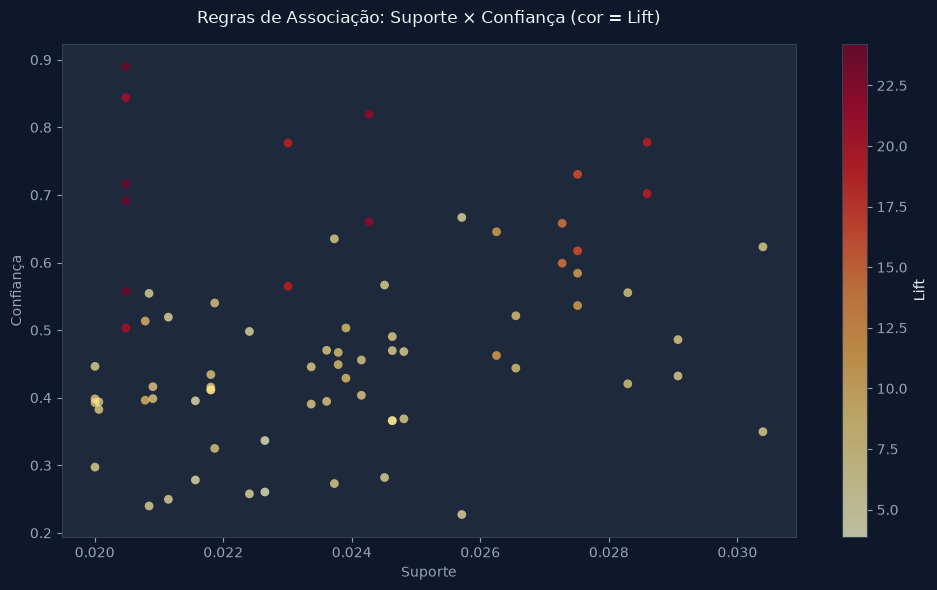

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    regras_filtradas['support'],
    regras_filtradas['confidence'],
    c=regras_filtradas['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='none',
    s=40
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Lift', color='#f1f5f9')
cbar.ax.yaxis.set_tick_params(color='#94a3b8')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#94a3b8')

ax.set_xlabel('Suporte')
ax.set_ylabel('Confiança')
ax.set_title('Regras de Associação: Suporte × Confiança (cor = Lift)', pad=15)

plt.tight_layout()
plt.show()

O gráfico revela um padrão típico em datasets de varejo: a maioria das regras concentra-se em valores baixos de suporte, o que reflete a diversidade do catálogo e a especificidade das combinações. As regras com lift mais alto (tons mais escuros) tendem a ter suporte menor, pois envolvem produtos de nicho que co-ocorrem com frequência relativa alta, mas em volume absoluto baixo. Já as regras com suporte alto geralmente envolvem produtos muito populares, o que tende a comprimir o lift pela alta frequência individual de cada item.



### 7.3 Tabela das top regras por lift

Apresento as dez regras com maior lift, formatando os itemsets para leitura direta.


In [28]:
top_regras = regras_filtradas.head(10).copy()
top_regras['antecedentes'] = top_regras['antecedents'].apply(lambda x: ', '.join(list(x)))
top_regras['consequentes'] = top_regras['consequents'].apply(lambda x: ', '.join(list(x)))

display_cols = ['antecedentes', 'consequentes', 'support', 'confidence', 'lift']
top_regras[display_cols].rename(columns={
    'support':    'suporte',
    'confidence': 'confiança',
    'lift':       'lift'
})

,antecedentes,consequentes,suporte,confiança,lift
0,"ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY...",GREEN REGENCY TEACUP AND SAUCER,0.020485,0.890339,24.216650
1,GREEN REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY...",0.020485,0.557190,24.216650
2,PINK REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER , GREEN REGENC...",0.020485,0.691684,24.188581
3,"ROSES REGENCY TEACUP AND SAUCER , GREEN REGENC...",PINK REGENCY TEACUP AND SAUCER,0.020485,0.716387,24.188581
4,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.024270,0.660131,22.289120
5,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.024270,0.819473,22.289120
6,"PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.020485,0.844059,20.723028
7,ROSES REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY ...",0.020485,0.502950,20.723028
8,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.028595,0.777778,19.095706
9,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.028595,0.702065,19.095706




As regras com lift mais alto revelam associações que vão além da popularidade individual dos produtos. Produtos que fazem parte de coleções ou linhas temáticas, como conjuntos de cozinha ou decoração, tendem a aparecer juntos com frequência desproporcional ao seu suporte individual, gerando lifts elevados. Esse é exatamente o tipo de padrão que não seria identificado por uma análise manual dos dados.



### 7.4 Regras mais confiantes vs. mais frequentes

Comparo as regras de maior confiança com as de maior suporte para ilustrar a diferença entre os dois critérios de ordenação.

In [29]:
print("=== Top 5 por confiança ===")
print(
    regras_filtradas
    .nlargest(5, 'confidence')[['antecedents', 'consequents', 'confidence', 'lift']]
    .to_string(index=False)
)

print("\n=== Top 5 por suporte ===")
print(
    regras_filtradas
    .nlargest(5, 'support')[['antecedents', 'consequents', 'support', 'lift']]
    .to_string(index=False)
)

=== Top 5 por confiança ===
                                                                  antecedents                                   consequents  confidence      lift
frozenset({ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY TEACUP AND SAUCER})  frozenset({GREEN REGENCY TEACUP AND SAUCER})    0.890339 24.216650
 frozenset({PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER}) frozenset({ROSES REGENCY TEACUP AND SAUCER })    0.844059 20.723028
                                  frozenset({PINK REGENCY TEACUP AND SAUCER})  frozenset({GREEN REGENCY TEACUP AND SAUCER})    0.819473 22.289120
                                 frozenset({GREEN REGENCY TEACUP AND SAUCER}) frozenset({ROSES REGENCY TEACUP AND SAUCER })    0.777778 19.095706
                                  frozenset({PINK REGENCY TEACUP AND SAUCER}) frozenset({ROSES REGENCY TEACUP AND SAUCER })    0.776876 19.073573

=== Top 5 por suporte ===
                                 antecedents                         

As regras de maior confiança indicam que, quando o antecedente aparece, o consequente quase sempre acompanha. Porém, se o suporte for muito baixo, essa associação vale para poucas transações e tem impacto operacional limitado. As regras de maior suporte, por outro lado, aparecem em muitas transações, mas a confiança pode ser moderada. Na prática, as regras mais acionáveis costumam ser aquelas que equilibram suporte razoável, confiança alta e lift expressivo.



---

## 8. Conclusão e Considerações Finais

### 8.1 Síntese do Projeto

Neste notebook percorri o processo KDD completo aplicado a dados transacionais reais. Parti de um dataset bruto com mais de um milhão de registros, identifiquei e removi inconsistências, transformei os dados para o formato matricial binário exigido pelo Apriori, executei o algoritmo e analisei as regras geradas com base nas métricas de suporte, confiança e lift.

### 8.2 Relevantes

O efeito dos limiares mínimos de suporte é não linear: uma redução de 5% para 2% no suporte mínimo pode multiplicar o número de itemsets por um fator considerável, enquanto a redução de 2% para 1% pode tornar o processamento inviável em notebooks locais sem otimizações. Esse comportamento reflete a natureza combinatória do Apriori, que avalia todas as combinações possíveis de itens antes de filtrar as frequentes. Em datasets de grande escala, algoritmos derivados como FP-Growth são preferíveis por construírem uma estrutura de árvore que evita a geração explícita de candidatos.

Outro ponto relevante é a distinção entre lift alto e utilidade prática. Regras com lift muito elevado frequentemente envolvem produtos com suporte muito baixo, o que significa que a associação é estatisticamente forte, mas ocorre em poucas transações. Para decisões de negócio como reorganização de prateleiras ou sistemas de recomendação, é necessário combinar lift com um suporte mínimo que garanta relevância operacional.

### 8.3 Limitações e Considerações

- A análise foi restrita ao mercado do Reino Unido. Padrões de compra em outros países presentes no dataset podem diferir significativamente e não foram explorados.
- O dataset contém transações de atacado e varejo misturadas. Pedidos com centenas de itens diferentes distorcem a noção de "cesta de compras" e podem inflar artificialmente certas associações.
- O Apriori foi aplicado com parâmetros fixos. Uma busca sistemática de hiperparâmetros (grid de suporte e confiança) poderia revelar configurações com melhor equilíbrio entre volume e qualidade das regras.
- Nenhuma análise temporal foi realizada. Padrões sazonais, como os das vendas de presentes próximas ao Natal, podem gerar associações que não se sustentam ao longo do ano inteiro.
- Este notebook tem finalidade exclusivamente educacional e documenta o estudo do curso de Mineração de Regras de Associação da IAExpert Academy.

---

## 9. Referências

IAEXPERT ACADEMY. **Mineração de Regras de Associação com Python, Apriori e SQL**. Disponível em: https://iaexpert.academy/cursos-online-assinatura/mineracao-regras-associacao-python-apriori-sql/. Acesso em: jun. 2026.

CHEN, D.; SAIN, S. L.; GUO, K. **Online Retail II**. UCI Machine Learning Repository, 2019. Disponível em: https://archive.ics.uci.edu/dataset/502/online+retail+ii. Acesso em: jun. 2026.

RASCHKA, S. **mlxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack**. The Journal of Open Source Software, v. 3, n. 24, 2018. Disponível em: https://rasbt.github.io/mlxtend/. Acesso em: jun. 2026.

PANDAS DEVELOPMENT TEAM. **pandas: powerful Python data analysis toolkit**. Disponível em: https://pandas.pydata.org/docs/. Acesso em: jun. 2026.

AGRAWAL, R.; SRIKANT, R. **Fast algorithms for mining association rules**. In: Proceedings of the 20th International Conference on Very Large Data Bases, 1994. p. 487-499.

---

> Material desenvolvido para estudos e composição de portfólio a partir de
> [IAExpert Academy](https://iaexpert.academy/cursos-online-assinatura/mineracao-regras-associacao-python-apriori-sql/), para o repositório
> [data-trivium](https://github.com/esscova/data-trivium);
> com auxílio do Claude Anthropic para revisões e estruturação.